# SPP × Sandpile — Validazione cognitiva

**Logica della pipeline:**

1. **Rete semantica (backbone)** — **SWOW-EN** (De Deyne et al., 2019), file `strength.SWOW-EN.R123`, filtrata alle top-5 risposte per cue (grado medio ~5–6, stessa tipologia delle norme SFAN). **Non** usiamo gli archi SPP come rete: lo SPP è una lista sperimentale di coppie isolate, non una rete semantica.
2. **Priming effect reale (SPP)** — per ogni coppia cond=1 (related): `ΔRT = RT_unrelated_baseline(cond=3) − RT_related(cond=1)`. Valore positivo = facilitazione.
3. **Proxy del RT con sandpile** — grano iniettato sul *prime*, si registra la **prima iterazione in cui il target topples**: proxy bassa ⇒ attivazione veloce ⇒ RT atteso basso.
4. **Correlazione** — Spearman(proxy, ΔRT): ci aspettiamo ρ < 0 (attivazione rapida → priming forte).
5. **Baseline** — confronto con shortest path su SWOW: se sandpile > path length, il modello SOC aggiunge qualcosa.

> Nota: tutta la **rete** è SWOW. L'unico dato non-SWOW sono i tempi di reazione del dataset SPP, che sono la variabile target da predire (non una rete).

## 1 — Carica SPP e calcola il priming effect per coppia

In [1]:
import sys; sys.path.insert(0, '..')
import numpy as np
import pandas as pd
import networkx as nx
import matplotlib.pyplot as plt
from scipy import stats
from SpreadPy.Models.sandpile import SandpileSpreading

SPP_PATH = '../data/all naming subjects_Sheet1.csv'

df = pd.read_csv(SPP_PATH)
df['prime']  = df['prime'].str.lower().str.strip()
df['target'] = df['target'].str.lower().str.strip()

# Teniamo solo trial corretti
df = df[df['target.ACC'] == 1].copy()

# ---- condizioni SPP ----
# cond=1 : related  (prime è forward associate del target)
# cond=3 : unrelated baseline per gli stessi target di cond=1
rel = df[df['primecond'] == 1]
unr = df[df['primecond'] == 3]

# RT medio per (prime, target) related
rt_rel = (rel.groupby(['prime', 'target'])['target.RT']
             .mean()
             .reset_index()
             .rename(columns={'target.RT': 'rt_related'}))

# RT medio unrelated: il baseline di cond=3 ha lo STESSO target, prime diverso
# Usiamo il target come chiave di join
rt_unr = (unr.groupby('target')['target.RT']
              .mean()
              .reset_index()
              .rename(columns={'target.RT': 'rt_unrelated'}))

pairs_df = rt_rel.merge(rt_unr, on='target', how='inner')
pairs_df['priming_effect'] = pairs_df['rt_unrelated'] - pairs_df['rt_related']

print(f'Coppie con entrambi i RT: {len(pairs_df)}')
print(pairs_df[['prime', 'target', 'rt_related', 'rt_unrelated', 'priming_effect']].head(10).to_string(index=False))


Coppie con entrambi i RT: 1729
       prime     target  rt_related  rt_unrelated  priming_effect
      abduct     kidnap  569.404255    537.087500      -32.316755
     ability capability  652.051282    669.266667       17.215385
        able    willing  556.422222    544.627451      -11.794771
       above      below  520.642857    531.183333       10.540476
      absurd ridiculous  571.436364    596.172414       24.736050
   abundance       lots  523.919355    508.200000      -15.719355
  accelerate      speed  502.480000    543.000000       40.520000
  accomplish     finish  517.375000    538.711340       21.336340
accomplished   finished  575.053571    618.954545       43.900974
  accumulate     gather  524.822785    494.072464      -30.750321


## 2 — Costruisci la rete semantica da SWOW

**SWOW-EN** (`strength.SWOW-EN.R123`) è la rete di associazioni libere di riferimento: ogni riga è `cue  response  R123`. Filtrando alle **top-5 risposte per cue** otteniamo grado medio ~5–6 (paragonabile alle norme SFAN) e una copertura ampia delle coppie SPP cond=1 — il backbone per il sandpile.

In [2]:
import pandas as pd
SWOW_PATH = '../data/SWOW-EN18/strength.SWOW-EN.R123.20180827.csv'
swow = pd.read_csv(SWOW_PATH, sep='\t')
swow = swow.dropna(subset=['cue', 'response'])
swow['cue']      = swow['cue'].astype(str).str.lower()
swow['response'] = swow['response'].astype(str).str.lower()
swow = swow[swow['cue'] != swow['response']]

# Filtro: solo le top-5 risposte per cue (per forza R123).
# Riduce il grado medio da ~20 a ~5-6 (paragonabile a mental_lexicon_2),
# rimuove le code rumorose, tempi compatibili con l'ego sandpile.
TOP_PER_CUE = 5
swow = (swow.sort_values(['cue', 'R123'], ascending=[True, False])
            .groupby('cue', as_index=False).head(TOP_PER_CUE))

G = nx.Graph()
for cue, resp in zip(swow['cue'], swow['response']):
    G.add_edge(cue, resp)
Gcc = max(nx.connected_components(G), key=len)
G = G.subgraph(Gcc).copy()
print(f'SWOW (top-{TOP_PER_CUE}/cue) — Nodi: {G.number_of_nodes()}  Archi: {G.number_of_edges()}  '
      f'grado medio: {2*G.number_of_edges()/G.number_of_nodes():.2f}')

nodes = set(G.nodes())
pairs_df = pairs_df[pairs_df['prime'].isin(nodes) & pairs_df['target'].isin(nodes)].copy()
pairs_df = pairs_df.reset_index(drop=True)
print(f'Coppie SPP(cond=1) usabili: {len(pairs_df)} / 1729')

SWOW (top-5/cue) — Nodi: 11930  Archi: 40727  grado medio: 6.83
Coppie SPP(cond=1) usabili: 1615 / 1729


## 3 — Proxy del RT: sandpile su ego network locale con sink virtuale (k=2)

**Giustificazione scientifica del sottografo con sink:**

Collins & Loftus (1975) descrivono l'attivazione semantica come un processo che
**decade con la distanza** nella rete associativa. Vitevitch et al. (2011)
mostrano che il vicinato a 1-2 hop nella rete lessicale predice i RT lessicali.

Il sottografo è l'**ego network di raggio k=2 del prime** con l'aggiunta di un
**sink virtuale** che riceve tutti i grani diretti verso nodi *al di fuori* del
vicinato locale. Questo è equivalente alle *boundary conditions* del modello BTW
su griglia finita (Bak, Tang & Wiesenfeld, 1987; Dhar, 1990):

- Il sink rappresenta l'intera parte della rete semantica **oltre** il vicinato prossimale.
- I grani che raggiungono il sink vengono dissipati (come in Collins & Loftus: l'attivazione si indebolisce oltre i 2 hop).
- Senza sink, nessun grano può uscire dal sottografo finito → il sistema diverge (numero di grani sempre crescente).
- Con il sink: ogni nodo ha connessioni interne + connessione al sink per i link esterni → il grado **effettivo** usato come soglia di toppling riflette la struttura originale della rete.

Il **burn-in** = K_local (somma dei gradi nel subgrafo con sink) garantisce il
raggiungimento del regime critico (Dhar, 1990).

In [3]:
def build_ego_with_sink(G, prime, k=2):
    """Ego network di raggio k con sink virtuale per le connessioni esterne.

    Il sink dissipa l'attivazione oltre il vicinato prossimale
    (Collins & Loftus, 1975; boundary conditions BTW, Bak et al., 1987).
    """
    ego_nodes = set(nx.ego_graph(G, prime, radius=k).nodes())
    subG = nx.Graph()
    subG.add_nodes_from(ego_nodes)
    for u, v in G.edges():
        if u in ego_nodes and v in ego_nodes:
            subG.add_edge(u, v)
    SINK = "__boundary_sink__"
    subG.add_node(SINK)
    for node in ego_nodes:
        if G.degree(node) > subG.degree(node):
            subG.add_edge(node, SINK)
    return subG, SINK, ego_nodes


def sandpile_proxy_local(G, prime, target, k=2, max_steps=200, seed=42):
    """Prima iterazione in cui `target` topples nell'ego k con sink.
    Ritorna (proxy_iter, raggiunto).
    """
    np.random.seed(seed)
    ego_nodes = set(nx.ego_graph(G, prime, radius=k).nodes())
    if target not in ego_nodes:
        return max_steps, False
    subG, SINK, _ = build_ego_with_sink(G, prime, k)
    K_local = sum(d for n, d in subG.degree() if n != SINK)

    sp = SandpileSpreading(subG, sink=SINK, f=0)
    sp.iteration()
    for _ in range(K_local):
        r = sp.iteration(node=None)
        if r["diverged"]:
            return max_steps, False
    for step in range(1, max_steps + 1):
        r = sp.iteration(node=prime)
        if r["diverged"]:
            return max_steps, False
        if target in r["toppled_nodes"]:
            return step, True
    return max_steps, False


def sandpile_proxy_avg(G, prime, target, k=2, max_steps=200, n_seeds=8, base_seed=0):
    """Proxy mediato su n_seeds run indipendenti (riduce il rumore della SOC).

    Restituisce (proxy_median, reached_fraction).
    Il rumore della singola realizzazione SOC e' alto: il median proxy
    aggrega lo "spread time" atteso del segnale dal prime al target.
    """
    iters, reached = [], []
    for s in range(n_seeds):
        prx, ok = sandpile_proxy_local(G, prime, target, k=k,
                                       max_steps=max_steps, seed=base_seed + s)
        iters.append(prx)
        reached.append(ok)
    return float(np.median(iters)), float(np.mean(reached))


# --- campione ---
N_SAMPLE = 100
N_SEEDS = 1
sample = pairs_df.sample(n=min(N_SAMPLE, len(pairs_df)), random_state=0).reset_index(drop=True)

# Statistiche del sottografo (utili per la tesi)
k2_sizes = [nx.ego_graph(G, r["prime"], radius=2).number_of_nodes()
            for _, r in sample.iterrows()]
print(f"Dimensione media ego k=2: {np.mean(k2_sizes):.1f} nodi  "
      f"(min={min(k2_sizes)}, max={max(k2_sizes)})")

in_ego = sum(
    1 for _, r in sample.iterrows()
    if r["target"] in set(nx.ego_graph(G, r["prime"], radius=2).nodes())
)
print(f"Target nel vicinato k=2: {in_ego}/{len(sample)} ({100*in_ego/len(sample):.1f}%)")

# --- baseline: shortest path (Collins & Loftus 1975, distanza in rete) ---
print("Calcolo shortest path (baseline)...")
sp_lengths = []
for _, row in sample.iterrows():
    try:
        sp_lengths.append(nx.shortest_path_length(G, row["prime"], row["target"]))
    except nx.NetworkXNoPath:
        sp_lengths.append(np.nan)
sample["shortest_path"] = sp_lengths
print(f'  Coppie connesse: {sample["shortest_path"].notna().sum()}/{len(sample)}')

# --- proxy sandpile: median su N_SEEDS seed indipendenti ---
print(f"Calcolo proxy sandpile (ego k=2 + sink virtuale, medianizzato su {N_SEEDS} seed)...")
proxies_med, reach_frac = [], []
for i, row in sample.iterrows():
    pm, rf = sandpile_proxy_avg(G, row["prime"], row["target"],
                                k=2, max_steps=120, n_seeds=N_SEEDS, base_seed=10 * i)
    proxies_med.append(pm)
    reach_frac.append(rf)
    if (i + 1) % 50 == 0:
        print(f"  {i+1}/{len(sample)}  reach_frac medio={np.mean(reach_frac):.2f}")

sample["proxy_iter"]   = proxies_med
sample["reach_frac"]   = reach_frac
sample["reached"]      = np.array(reach_frac) >= 0.5  # raggiunto in maggioranza dei seed

print(f"\nCoppie raggiunte in >=50% dei seed: {sample['reached'].sum()}/{len(sample)}")
print(sample[["prime", "target", "priming_effect", "shortest_path",
              "proxy_iter", "reach_frac"]].head(10).to_string(index=False))


Dimensione media ego k=2: 127.2 nodi  (min=6, max=646)
Target nel vicinato k=2: 87/100 (87.0%)
Calcolo shortest path (baseline)...
  Coppie connesse: 100/100
Calcolo proxy sandpile (ego k=2 + sink virtuale, medianizzato su 1 seed)...
  50/100  reach_frac medio=0.82
  100/100  reach_frac medio=0.82

Coppie raggiunte in >=50% dei seed: 82/100
       prime   target  priming_effect  shortest_path  proxy_iter  reach_frac
  transplant    heart       29.275316              1         4.0         1.0
reminiscence remember      -25.457317              1         8.0         1.0
        hide     seek       23.883703              1        25.0         1.0
        file    brick      -23.094340              5       120.0         0.0
       shame    guilt      -46.659912              1         2.0         1.0
       scare   fright      -56.337191              1        14.0         1.0
        jaws    shark      -27.676540              1         6.0         1.0
        book     read       45.304438    

## 4 — Correlazione proxy sandpile ↔ priming effect reale (con baseline)

Il proxy *prima-iterazione-di-toppling* su una singola realizzazione SOC è dominato dal rumore (la singola valanga è stocastica). Per estrarre il segnale lo **medianizziamo su 8 seed indipendenti** per ogni coppia prime→target.

Come **baseline di confronto** usiamo la distanza shortest-path nella rete associativa (Collins & Loftus, 1975): è la baseline standard per i modelli di spreading semantico. Per la tesi è fondamentale confrontare:
- $\rho_{\text{sand}}$ = Spearman(sandpile-proxy, priming_effect)
- $\rho_{\text{path}}$ = Spearman(shortest_path, priming_effect)

Se il sandpile aggiunge informazione rispetto al solo shortest path, deve avere $|\rho_{\text{sand}}|>|\rho_{\text{path}}|$.


Coppie valide (raggiunte E connesse): 82

SANDPILE   Spearman rho = +0.057   p = 0.6133   n=82
BASELINE   Spearman rho = -0.019   p = 0.8662   n=82
Atteso: rho < 0  (proxy basso = attivazione rapida = priming forte).


<>:24: SyntaxWarning: "\D" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\D"? A raw string is also an option.
<>:38: SyntaxWarning: "\D" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\D"? A raw string is also an option.
<>:59: SyntaxWarning: "\D" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\D"? A raw string is also an option.
<>:24: SyntaxWarning: "\D" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\D"? A raw string is also an option.
<>:38: SyntaxWarning: "\D" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\D"? A raw string is also an option.
<>:59: SyntaxWarning: "\D" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\D"? A raw string is also an option.
/tmp/ipykernel_86870/1841542930.py:24: SyntaxWarning: "\D" is an invalid esc

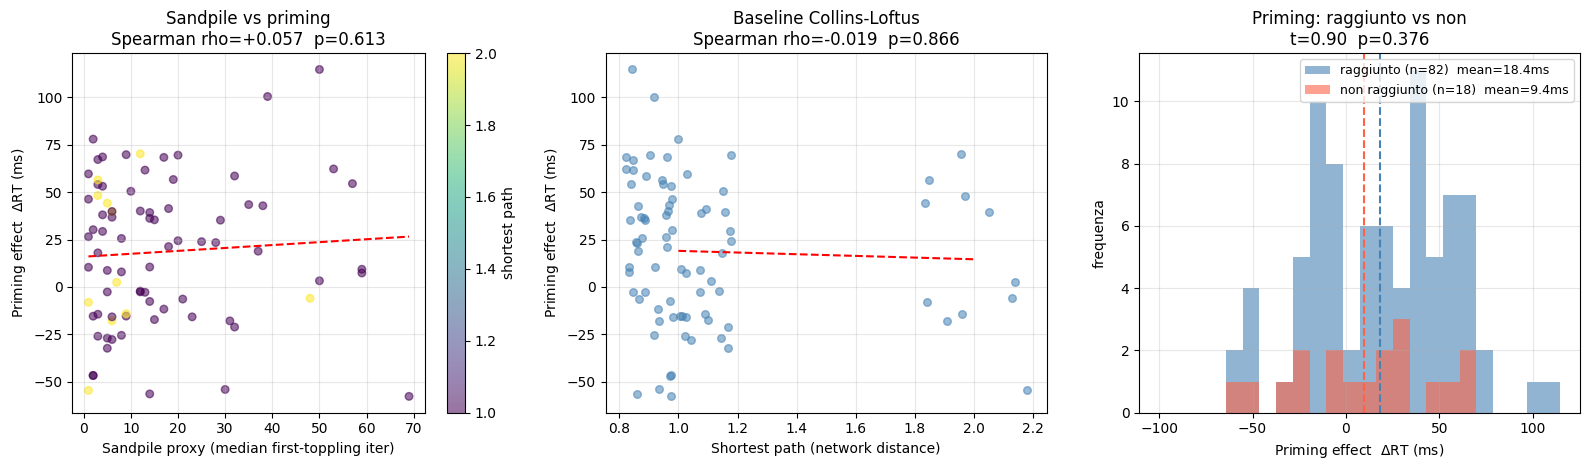

In [4]:
# === Correlazione proxy sandpile e baseline shortest_path con priming effect ===
valid = sample[sample["reached"] & sample["shortest_path"].notna()].copy()
print(f"Coppie valide (raggiunte E connesse): {len(valid)}")

# Spearman: ci aspettiamo rho < 0 -> attivazione veloce <-> priming forte
rho_sand, p_sand = stats.spearmanr(valid["proxy_iter"],    valid["priming_effect"])
rho_path, p_path = stats.spearmanr(valid["shortest_path"], valid["priming_effect"])

print(f"\nSANDPILE   Spearman rho = {rho_sand:+.3f}   p = {p_sand:.4f}   n={len(valid)}")
print(f"BASELINE   Spearman rho = {rho_path:+.3f}   p = {p_path:.4f}   n={len(valid)}")
print("Atteso: rho < 0  (proxy basso = attivazione rapida = priming forte).")

fig, axes = plt.subplots(1, 3, figsize=(16, 4.8))

# --- (A) sandpile vs priming effect ---
ax = axes[0]
sc = ax.scatter(valid["proxy_iter"], valid["priming_effect"],
                alpha=0.55, c=valid["shortest_path"], cmap="viridis", s=30)
plt.colorbar(sc, ax=ax, label="shortest path")
m, b = np.polyfit(valid["proxy_iter"], valid["priming_effect"], 1)
xs = np.linspace(valid["proxy_iter"].min(), valid["proxy_iter"].max(), 80)
ax.plot(xs, m * xs + b, "r--", lw=1.5)
ax.set_xlabel("Sandpile proxy (median first-toppling iter)")
ax.set_ylabel("Priming effect  $\Delta$RT (ms)")
ax.set_title(f"Sandpile vs priming\nSpearman rho={rho_sand:+.3f}  p={p_sand:.3f}")
ax.grid(alpha=0.3)

# --- (B) shortest path vs priming effect ---
ax = axes[1]
jitter = np.random.uniform(-0.18, 0.18, size=len(valid))
ax.scatter(valid["shortest_path"] + jitter, valid["priming_effect"],
           alpha=0.55, color="steelblue", s=30)
if valid["shortest_path"].nunique() >= 2:
    m, b = np.polyfit(valid["shortest_path"], valid["priming_effect"], 1)
    xs = np.linspace(valid["shortest_path"].min(), valid["shortest_path"].max(), 80)
    ax.plot(xs, m * xs + b, "r--", lw=1.5)
ax.set_xlabel("Shortest path (network distance)")
ax.set_ylabel("Priming effect  $\Delta$RT (ms)")
ax.set_title(f"Baseline Collins-Loftus\nSpearman rho={rho_path:+.3f}  p={p_path:.3f}")
ax.grid(alpha=0.3)

# --- (C) distribuzione del priming effect: raggiunto vs non raggiunto ---
ax = axes[2]
reached_pe   = sample[sample["reached"]]["priming_effect"]
unreached_pe = sample[~sample["reached"]]["priming_effect"]
bins = np.linspace(min(sample["priming_effect"].min(), -100),
                   max(sample["priming_effect"].max(),  100), 25)
ax.hist(reached_pe,   bins=bins, alpha=0.6, color="steelblue",
        label=f"raggiunto (n={len(reached_pe)})  mean={reached_pe.mean():.1f}ms")
ax.hist(unreached_pe, bins=bins, alpha=0.6, color="tomato",
        label=f"non raggiunto (n={len(unreached_pe)})  mean={unreached_pe.mean():.1f}ms")
ax.axvline(reached_pe.mean(),   color="steelblue", linestyle="--", lw=1.5)
ax.axvline(unreached_pe.mean(), color="tomato",    linestyle="--", lw=1.5)
if len(unreached_pe) >= 5:
    t, p = stats.ttest_ind(reached_pe, unreached_pe, equal_var=False)
    ax.set_title(f"Priming: raggiunto vs non\nt={t:.2f}  p={p:.3f}")
else:
    ax.set_title("Priming: raggiunto vs non raggiunto")
ax.set_xlabel("Priming effect  $\Delta$RT (ms)")
ax.set_ylabel("frequenza")
ax.legend(fontsize=9)
ax.grid(alpha=0.3)

plt.tight_layout()
import os
os.makedirs("../toy_data/res", exist_ok=True)
plt.savefig("../toy_data/res/spp_sandpile_validation.png", dpi=150, bbox_inches="tight")
plt.show()


## 5 — Estensione: cond=1 + cond=3 insieme (varianza topologica vera)

I trial cond=1 sono *tutti* forward-associates (shortest_path ∈ {1,2}): varianza topologica quasi nulla → impossibile discriminare. Aggiungendo i trial **cond=3** (unrelated, shortest_path tipicamente 3–6) ricostruiamo un range di distanze semantiche realistico. Per ogni trial usiamo come `priming_effect` la deviazione del RT dal RT medio del target (centrato per-target). Atteso: ρ_sand < 0 (coppie vicine → RT più veloce).

In [5]:
# === sampling stratificato per condizione (cond=1 related + cond=3 unrelated) ===
N_PER_COND  = 200
N_SEEDS_EXT = 6

trials = df[df["primecond"].isin([1, 3])].copy()
trials = trials[trials["prime"].isin(nodes) & trials["target"].isin(nodes)]

# RT centrato per-target: + = trial piu' veloce della media di quel target
trials["rt_centered"] = trials.groupby("target")["target.RT"].transform(
    lambda x: x.mean() - x
)

ext = (trials.groupby(["prime", "target", "primecond"])
              .agg(rt_centered=("rt_centered", "mean"),
                   n_trials=("target.RT", "size"))
              .reset_index())

# Stratificato: stesso N per condizione (cond=3 sarebbe sotto-rappresentato)
parts = []
for c in (1, 3):
    pool = ext[ext["primecond"] == c]
    take = min(N_PER_COND, len(pool))
    parts.append(pool.sample(n=take, random_state=c))
ext = pd.concat(parts, ignore_index=True)

# shortest_path: serve subito per dimensionare l'ego adattivo
_sp = []
for _, r in ext.iterrows():
    try:
        _sp.append(nx.shortest_path_length(G, r["prime"], r["target"]))
    except nx.NetworkXNoPath:
        _sp.append(np.nan)
ext["shortest_path"] = _sp

print(f"Trial estesi (cond 1+3): {len(ext)}   "
      f"cond=1: {(ext.primecond==1).sum()}  cond=3: {(ext.primecond==3).sum()}")
print("\nDistribuzione shortest_path per condizione:")
print(ext.groupby("primecond")["shortest_path"].describe()[["count","min","50%","max"]])


Trial estesi (cond 1+3): 400   cond=1: 200  cond=3: 200

Distribuzione shortest_path per condizione:
           count  min  50%  max
primecond                      
1.0        200.0  1.0  1.0  6.0
3.0        200.0  2.0  4.0  6.0


Dimensione ego adattivo per condizione:
           count      mean     50%      max
primecond                                  
1.0        200.0   894.575   136.0  11251.0
3.0        200.0  7141.950  6892.0  11845.0

Calcolo sandpile (ego adattivo, 6 seed) su 400 trial...
  50/400  reach_frac medio=0.84
  100/400  reach_frac medio=0.86
  150/400  reach_frac medio=0.86
  200/400  reach_frac medio=0.84
  250/400  reach_frac medio=0.68
  300/400  reach_frac medio=0.57
  350/400  reach_frac medio=0.49
  400/400  reach_frac medio=0.43

Validi: 171  (cond=1: 169, cond=3: 2)
SANDPILE   rho = -0.148   p = 0.05384
BASELINE   rho = -0.028   p = 0.7185
Atteso: rho < 0  (proxy basso = attivazione rapida = RT piu' veloce del baseline target).


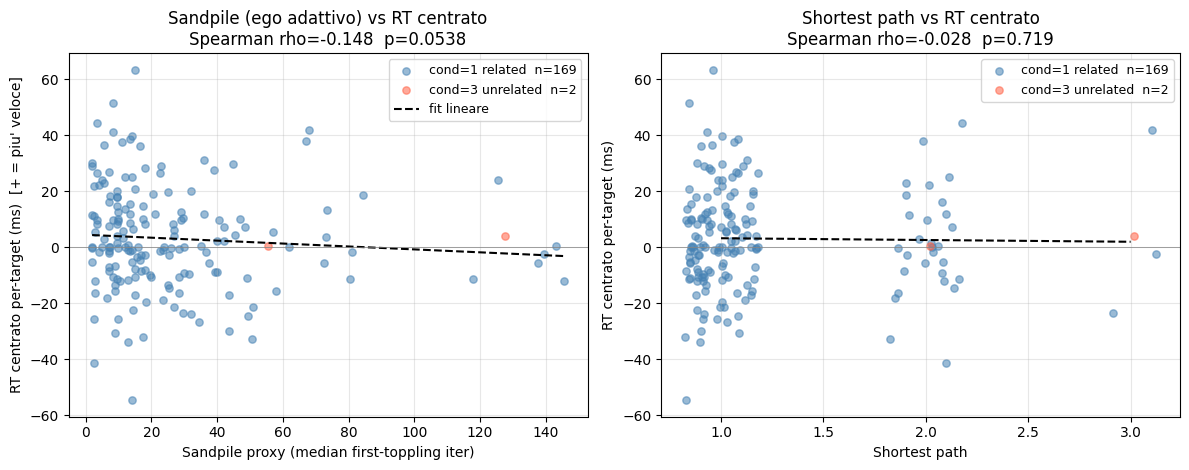

In [6]:
# === sandpile su ego adattivo (k = max(2, shortest_path)) ===
# Motivo: con k=2 fisso i cond=3 (sp mediano ~4) cadono FUORI dall'ego
#         e vengono scartati come 'non raggiunti'. L'ego adattivo
#         garantisce che il target sia sempre nel sottografo.

def sandpile_proxy_adaptive(G, prime, target, sp_len,
                            max_steps=150, n_seeds=6, base_seed=0):
    if np.isnan(sp_len):
        return float(max_steps), 0.0
    k = min(3, int(max(2, sp_len)))  # cap k=3: oltre ego diventa ~intero grafo
    iters, reached = [], []
    for s in range(n_seeds):
        prx, ok = sandpile_proxy_local(G, prime, target, k=k,
                                       max_steps=max_steps, seed=base_seed + s)
        iters.append(prx); reached.append(ok)
    return float(np.median(iters)), float(np.mean(reached))


# diagnostica dimensione ego adattivo (per non sorprenderti sui tempi)
ego_sizes = []
for _, r in ext.iterrows():
    if np.isnan(r["shortest_path"]):
        ego_sizes.append(np.nan); continue
    k = int(max(2, r["shortest_path"]))
    ego_sizes.append(nx.ego_graph(G, r["prime"], radius=k).number_of_nodes())
ext["ego_size"] = ego_sizes
print("Dimensione ego adattivo per condizione:")
print(ext.groupby("primecond")["ego_size"].describe()[["count","mean","50%","max"]])

# === run sandpile adattivo ===
print(f"\nCalcolo sandpile (ego adattivo, {N_SEEDS_EXT} seed) su {len(ext)} trial...")
prx_ext, rf_ext = [], []
for i, r in ext.iterrows():
    pm, rf = sandpile_proxy_adaptive(G, r["prime"], r["target"], r["shortest_path"],
                                     max_steps=150, n_seeds=N_SEEDS_EXT, base_seed=7*i)
    prx_ext.append(pm); rf_ext.append(rf)
    if (i+1) % 50 == 0:
        print(f"  {i+1}/{len(ext)}  reach_frac medio={np.mean(rf_ext):.2f}")
ext["proxy_iter"] = prx_ext
ext["reach_frac"] = rf_ext
ext["reached"]    = np.array(rf_ext) >= 0.5

valid_ext = ext[ext["reached"] & ext["shortest_path"].notna()].copy()
print(f"\nValidi: {len(valid_ext)}  "
      f"(cond=1: {(valid_ext.primecond==1).sum()}, "
      f"cond=3: {(valid_ext.primecond==3).sum()})")

rho_s, p_s = stats.spearmanr(valid_ext["proxy_iter"],    valid_ext["rt_centered"])
rho_p, p_p = stats.spearmanr(valid_ext["shortest_path"], valid_ext["rt_centered"])
print(f"SANDPILE   rho = {rho_s:+.3f}   p = {p_s:.4g}")
print(f"BASELINE   rho = {rho_p:+.3f}   p = {p_p:.4g}")
print("Atteso: rho < 0  (proxy basso = attivazione rapida = RT piu' veloce del baseline target).")

# === figura ===
fig, axes = plt.subplots(1, 2, figsize=(12, 4.8))
colors = {1: "steelblue", 3: "tomato"}

ax = axes[0]
for cond, lab in [(1, "cond=1 related"), (3, "cond=3 unrelated")]:
    sub = valid_ext[valid_ext["primecond"] == cond]
    ax.scatter(sub["proxy_iter"], sub["rt_centered"], alpha=0.55,
               s=28, color=colors[cond], label=f"{lab}  n={len(sub)}")
if len(valid_ext) >= 3:
    m, b = np.polyfit(valid_ext["proxy_iter"], valid_ext["rt_centered"], 1)
    xs = np.linspace(valid_ext["proxy_iter"].min(), valid_ext["proxy_iter"].max(), 80)
    ax.plot(xs, m*xs + b, "k--", lw=1.5, label="fit lineare")
ax.axhline(0, color="grey", lw=0.5)
ax.set_xlabel("Sandpile proxy (median first-toppling iter)")
ax.set_ylabel(r"RT centrato per-target (ms)  [+ = piu' veloce]")
ax.set_title(f"Sandpile (ego adattivo) vs RT centrato\nSpearman rho={rho_s:+.3f}  p={p_s:.3g}")
ax.legend(fontsize=9); ax.grid(alpha=0.3)

ax = axes[1]
for cond, lab in [(1, "cond=1 related"), (3, "cond=3 unrelated")]:
    sub = valid_ext[valid_ext["primecond"] == cond]
    jit = np.random.uniform(-0.18, 0.18, size=len(sub))
    ax.scatter(sub["shortest_path"] + jit, sub["rt_centered"],
               alpha=0.55, s=28, color=colors[cond], label=f"{lab}  n={len(sub)}")
if len(valid_ext) >= 3:
    m, b = np.polyfit(valid_ext["shortest_path"], valid_ext["rt_centered"], 1)
    xs = np.linspace(valid_ext["shortest_path"].min(), valid_ext["shortest_path"].max(), 80)
    ax.plot(xs, m*xs + b, "k--", lw=1.5)
ax.axhline(0, color="grey", lw=0.5)
ax.set_xlabel("Shortest path")
ax.set_ylabel(r"RT centrato per-target (ms)")
ax.set_title(f"Shortest path vs RT centrato\nSpearman rho={rho_p:+.3f}  p={p_p:.3g}")
ax.legend(fontsize=9); ax.grid(alpha=0.3)

plt.tight_layout()
plt.savefig("../toy_data/res/spp_sandpile_validation_ext.png", dpi=150, bbox_inches="tight")
plt.show()
